In [ ]:
!pip install stable_baselines3
!pip install gymnasium[atari,accept-rom-license]
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import os
import random
import time

import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from stable_baselines3.common.atari_wrappers import (
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
from stable_baselines3.common.buffers import ReplayBuffer

In [ ]:
# settings
env_id  = "BreakoutNoFrameskip-v4"

# number of environments to run in parallel
num_envs = 1

# total number of timesteps for training over multiple episodes
total_timesteps = 5_000_000

# adam learning rate
learning_rate = 1e-4

# number of transitions to store in replay buffer
buffer_size = 250_000

# discount factor
gamma = 0.99

# target network update constant
# θ_target = 𝜏 * θ + (1 - 𝜏) * θ_target
tau = 1.0

# number of timesteps between target network updates
target_network_frequency = 1000

# size of sample from replay buffer
batch_size = 32

# initial value of epsilon (100% exploration)
start_eps = 1

# final value of epsilon (1% exploration)
end_eps = 0.01

# number of steps to decrease from start_eps to end_eps
exploration_duration = 1_000_000

# number of steps before beginning training
num_steps_before_training = 80_000

# number of steps between each gradient descent step
train_frequency = 4

# optional: set seed for reproducibility
# seed = 123
seed = None

In [ ]:
# will encapsulate in lambda later
def make_env(env_id, capture_video, seed=None):
  if capture_video:
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(env, "videos",
                                   episode_trigger=lambda episode: True)
  else:
    env = gym.make(env_id)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  env = NoopResetEnv(env, noop_max=30)
  env = MaxAndSkipEnv(env, skip=4)
  env = EpisodicLifeEnv(env)

  if "FIRE" in env.unwrapped.get_action_meanings():
    env = FireResetEnv(env)
  env = ClipRewardEnv(env)

  env = gym.wrappers.ResizeObservation(env, (84, 84))
  env = gym.wrappers.GrayscaleObservation(env)
  env = gym.wrappers.FrameStackObservation(env, 4)

  # for reproducibility
  if seed is not None:
    env.action_space.seed(seed)
  return env

In [ ]:
class QNetwork(nn.Module):
  def __init__(self, envs):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(4, 32, kernel_size=8, stride=4),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3136, 512),
        nn.ReLU(),
        nn.Linear(512, envs.single_action_space.n),
    )

  def forward(self, x):
    return self.network(x / 255.0)

In [ ]:
def linear_schedule(start_eps: float, end_eps: float, duration: int, t: int):
  slope = (end_eps - start_eps) / duration
  return max(slope * t + start_eps, end_eps)

In [ ]:
# optional: set seeds for reproducibility
if seed is not None:
  torch.manual_seed(seed)
  random.seed(seed)
  np.random.seed(seed)
  if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [ ]:
# note: vector environment does nice things for us, namely:
# 1) returns numpy arrays for observations instead of LazyFrames objects
#    (easier to work with)
# 2) accumulates total return / reward per episode so we don't have to
#    track it ourselves
# 3) because of our wrappers (reward clipping), we don't know the REAL return
envs = gym.vector.SyncVectorEnv([
    lambda: make_env(
        env_id,
        False,
        None if seed is None else seed + i) for i in range(num_envs)
], autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)

In [ ]:
# set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# On Mac, MPS faster than CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [ ]:
# make neural networks
q_network = QNetwork(envs).to(device)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
target_network = QNetwork(envs).to(device)
target_network.load_state_dict(q_network.state_dict())

<All keys matched successfully>

In [ ]:
rb = ReplayBuffer(
    buffer_size,
    envs.single_observation_space,
    envs.single_action_space,
    device,
    optimize_memory_usage=True,
    handle_timeout_termination=False,
)

In [ ]:
def np2torch(a, dtype=torch.float32, device=device):
  return torch.as_tensor(a, dtype=dtype, device=device)

In [ ]:
# training loop

episode_returns = []
losses = []

In [ ]:
start_time = time.time()
obs, _ = envs.reset(seed=seed)

for global_step in range(total_timesteps):

  # select action based on epsilon-greedy strategy
  epsilon = linear_schedule(start_eps, end_eps, exploration_duration, global_step)
  if random.random() < epsilon:
    actions = np.array(
        [envs.single_action_space.sample() for _ in range(num_envs)]
    )
  else:
    q_values = q_network(np2torch(obs))
    actions = torch.argmax(q_values, dim=1).cpu().numpy()

  # take a step in the environment
  next_obs, rewards, dones, truncateds, infos = envs.step(actions)

  for i, (done, truncated) in enumerate(zip(dones, truncateds)):
    if done or truncated:
      # This only appears when all lives are lost
      if 'episode' in infos['final_info']:
        ret = infos['final_info']['episode']['r'][0]
        episode_returns.append(ret)
        print(f"global_step={global_step}, episode={len(episode_returns)}, episode_return={ret}")

  # since we use same step
  real_next_obs = next_obs.copy()
  for i, truncated in enumerate(truncateds):
    if truncated:
      real_next_obs[i] = infos["final_obs"][i]
  rb.add(obs, real_next_obs, actions, rewards, dones, infos)

  # don't forget
  obs = next_obs

  # training
  if global_step > num_steps_before_training:
    if global_step % train_frequency == 0:
      data = rb.sample(batch_size)
      with torch.no_grad():
        target_max, _ = target_network(data.next_observations).max(dim=1)
        td_target = data.rewards.flatten() + \
          gamma * target_max * (1 - data.dones.flatten())
      # q_network(obs)[:, actions]
      pred = q_network(data.observations).gather(1, data.actions).squeeze()
      loss = F.mse_loss(pred, td_target)
      losses.append(loss.item())

      # optimize model
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if global_step % 100 == 0:
        print("steps per second:", int(global_step / (time.time() - start_time)))

      # update target network
      if global_step % target_network_frequency == 0:
        for target_network_param, q_network_param in zip(
            target_network.parameters(), q_network.parameters()
        ):
          target_network_param.data.copy_(
              tau * q_network_param.data + (1.0 - tau) * target_network_param.data
          )

# close env
envs.close()

global_step=112, episode=1, episode_return=0.0
global_step=326, episode=2, episode_return=3.0
global_step=437, episode=3, episode_return=0.0
global_step=550, episode=4, episode_return=0.0
global_step=665, episode=5, episode_return=0.0
global_step=778, episode=6, episode_return=0.0
global_step=1114, episode=7, episode_return=5.0
global_step=1252, episode=8, episode_return=1.0
global_step=1367, episode=9, episode_return=0.0
global_step=1482, episode=10, episode_return=0.0
global_step=1646, episode=11, episode_return=1.0
global_step=1761, episode=12, episode_return=0.0
global_step=1902, episode=13, episode_return=1.0
global_step=2013, episode=14, episode_return=0.0
global_step=2126, episode=15, episode_return=0.0
global_step=2342, episode=16, episode_return=3.0
global_step=2451, episode=17, episode_return=0.0
global_step=2562, episode=18, episode_return=0.0
global_step=2752, episode=19, episode_return=2.0
global_step=2911, episode=20, episode_return=1.0
global_step=3024, episode=21, episo

KeyboardInterrupt: 

In [ ]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1 - a) * y[-1]
        y.append(yi)
    return y

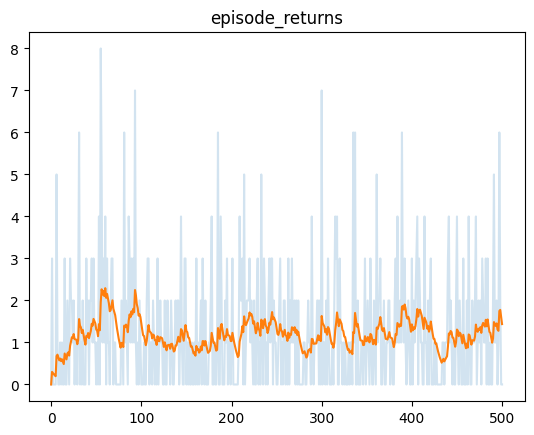

In [ ]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");

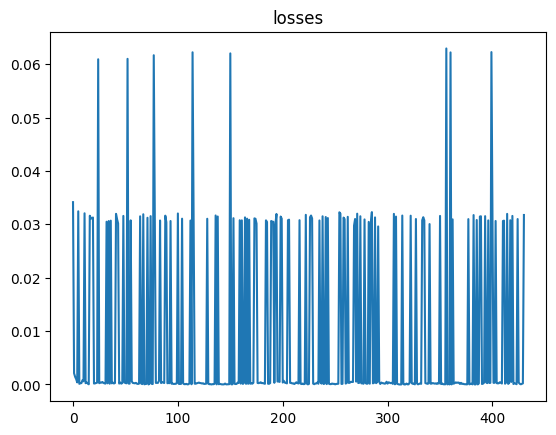

In [ ]:
plt.plot(losses)
plt.title("losses");

In [ ]:
# save model
model_path = "dqn_atari_gym1.pth"
torch.save(q_network.state_dict(), model_path)

In [ ]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
model = QNetwork(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

QNetwork(
  (network): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=512, bias=True)
    (8): ReLU()
    (9): Linear(in_features=512, out_features=4, bias=True)
  )
)

In [ ]:
from tokenize import N_TOKENS
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    if random.random() < epsilon:
      actions = np.array(
          [envs_eval.single_action_space.sample() for _ in range(envs_eval.num_envs)]
      )
    else:
      q_values = model(np2torch(obs))
      actions = torch.argmax(q_values, dim=1).cpu().numpy()
    obs, rewards, dones, truncateds, infos = envs_eval.step(actions)

    if dones[0] or truncateds[0]:
      if 'final_info' in infos:
        if 'episode' in infos['final_info']:
          episode_done = True
          ret = infos['final_info']['episode']['r'][0]
          eval_returns[i] = ret
          print(f"episode={i}, episode_return={ret}")

envs_eval.close()

/usr/local/lib/python3.11/dist-packages/moviepy/config_defaults.py:1: DeprecationWarning: invalid escape sequence '\P'
  """


episode=0, episode_return=0.0
episode=1, episode_return=0.0
episode=2, episode_return=0.0
episode=3, episode_return=0.0
episode=4, episode_return=0.0
episode=5, episode_return=1.0
episode=6, episode_return=1.0
episode=7, episode_return=0.0
episode=8, episode_return=1.0
episode=9, episode_return=0.0


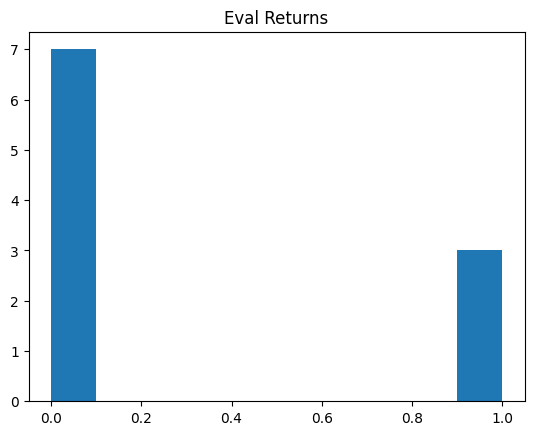

In [ ]:
# plot the eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns");

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=83SBIReT_VK9g4jXKsbP_w&n=DQN+Atari)